In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [5]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv2
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_maskv2(particles)
particles


Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...


event_id,is_target_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
122,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[50, 51, … 3400]","[111, 2212, … 11]","[0.13498, 0.93827, … 0.000511]","[25.069691, 74.01371, … 0.001132]","[0.0, 1.0, … -1.0]","[-0.017536, -0.017536, … -247.586166]","[0.004952, 0.004952, … -613.687073]","[22.533466, 22.533466, … -293.825012]","[0.139495, 0.139495, … 2.600593]","[-1.21785, -2.679107, … 0.000539]","[0.949296, 2.117662, … 0.000854]","[25.021727, 73.928925, … -0.000035]","[0.006875, 0.00699, … NaN]","[22.26001, 22.169159, … NaN]","[1, 1, … 1]","[9, 9, … 3347]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[3.479385, 3.768612, … -0.034641]","[2.479487, 2.472711, … 1.007645]","[1.544125, 3.414983, … 0.00101]"
777,"[false, true, … false]","[false, true, … false]","[false, true, … false]","[165, 166, … 8850]","[-521, 321, … 2212]","[5.27925, 0.49368, … 0.938272]","[156.945114, 13.257682, … 1.045295]","[-1.0, 1.0, … 1.0]","[0.001572, 0.001572, … 961.811951]","[-0.008819, -0.008819, … -1098.893433]","[44.240398, 44.240398, … 2862.112305]","[0.269996, 0.269996, … 10.950574]","[52.709202, 4.705897, … -0.0691]","[-51.386688, -2.920094, … -0.449419]","[138.510086, 12.035363, … 0.074393]","[-0.005217, -0.006665, … NaN]","[44.226696, 44.227386, … NaN]","[1, 1, … 1]","[9, 9, … 8782]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[1.389397, 1.518484, … 0.162889]","[-0.772694, -0.55537, … -1.723355]","[73.612846, 5.538269, … 0.4547]"
256,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[37, 38, … 9647]","[211, 223, … 11]","[0.13957, 0.787747, … 0.000511]","[376.100769, 846.893311, … 0.125725]","[1.0, 0.0, … -1.0]","[-0.029784, -0.029784, … -393.848755]","[-0.012256, -0.012256, … 1251.669922]","[-73.520294, -73.520294, … -2848.599365]","[-0.134761, -0.134761, … 10.227237]","[-0.478596, 0.93805, … -0.025176]","[0.234532, -0.513545, … -0.10697]","[376.100372, 846.892212, … -0.061075]","[NaN, 0.0, … -670.123901]","[NaN, 0.0, … -3475.590332]","[1, 1, … 1]","[10, 10, … 9644]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[7.252291, 7.367602, … -0.530528]","[2.685943, -0.500891, … -1.801943]","[0.532972, 1.069423, … 0.109892]"
911,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[91, 92, … 4775]","[311, -321, … 11]","[0.49761, 0.49368, … 0.000511]","[1470.352173, 2078.260986, … 0.120716]","[0.0, -1.0, … -1.0]","[-0.005466, -0.005466, … 339.499176]","[0.00265, 0.00265, … -119.505211]","[-24.467728, -24.467728, … -4027.736572]","[0.316079, 0.316079, … 13.723409]","[0.418056, -0.324387, … 0.010329]","[0.004876, -0.332179, … -0.003468]","[1470.352051, 2078.260742, … -0.120223]","[0.0, NaN, … 201.856216]","[0.0, NaN, … 4759.178711]","[1, 1, … 1]","[12, 12, … 4771]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[8.858478, 9.099669, … -3.096182]","[0.011662, -2.344327, … -0.323931]","[0.418084, 0.464296, … 0.010896]"
783,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[17, 18, … 5243]","[22, 211, … 11]","[0.0, 0.13957, … 0.000511]","[170.337784, 826.29895, … 0.106319]","[0.0, 1.0, … -1.0]","[0.008565, 0.008565, … -1261.445679]","[0.004144, 0.004144, … 30.636801]","[72.07193, 72.07193, … 2143.757812]","[-0.024572, -0.024572, … 8.066792]","[1.261075, -0.043473, … -0.05584]","[0.504627, 0.324209, … 0.004208]","[170.332367, 826.298889, … 0.090374]","[0.0, NaN, … NaN]","[0.0, NaN, … NaN]","[1, 1, …

In [8]:
target_particles = (
particles.lazy()
.select(['event_id', 'particle_id', 'is_target_particle', 'pdg_id',
            'energy', 'eta', 'phi', 'px', 'py', 'pz', 'pt',
            'charge','mass', 'has_track'])
.explode( 'particle_id', 'is_target_particle', 'pdg_id',
            'energy', 'eta', 'phi', 'px', 'py', 'pz', 'pt',
            'charge','mass', 'has_track')
.filter(pl.col('is_target_particle'))
.sort('event_id')
.with_row_index("global_order")
.sort('global_order')
.drop('is_target_particle', 'global_order')
.group_by('event_id', maintain_order=True)
.agg('*')
.collect(streaming=True)
)

target_particles_idx =  (
    target_particles.lazy()
    .select(['event_id', 'particle_id'])
    .explode('particle_id')
    .with_row_index('particle_idx')
    .group_by('event_id', maintain_order=True)
    .agg([
        pl.col('particle_id'),
        (pl.col('particle_idx') - pl.col('particle_idx').min()).alias('particle_idx')
    ])
    .explode(['particle_id', 'particle_idx'])
    .collect()
)
tracks_mappings = (
    tracks.lazy()
    .select(['event_id', 'majority_particle_id'])
    .with_columns(
        # FIX: Use 'int_ranges' (plural) to generate a range for every row
        local_order=pl.int_ranges(
            start=0,
            end=pl.col('majority_particle_id').list.len(), 
            dtype=pl.UInt32
        )
    )
    .explode(['majority_particle_id', 'local_order'])
    .rename({'majority_particle_id': 'particle_id'})
    .join(
        target_particles_idx.lazy(),
        on=['event_id', 'particle_id'],
        how='inner'
    )
    .group_by('event_id')
    .agg(
        pl.col('particle_idx').sort_by('local_order')
    )
).collect()

/tmp/ipykernel_1760650/4006829385.py:16: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


In [11]:
tracks_mappings.filter(pl.col('event_id')==1).select(pl.col('particle_idx').explode())

particle_idx
u32
28
1
5
6
2
…
36
32
39


In [7]:
(particles
 .select(['event_id','particle_id', 'has_track', 'is_target_particle', 'pt', 'eta'])
 .explode('particle_id', 'has_track', 'is_target_particle', 'pt', 'eta')
 .filter((pl.col('has_track')) 
         & (pl.col('pt')>0.5) & (pl.col('eta').abs()<3.5)
         ))

event_id,particle_id,has_track,is_target_particle,pt,eta
u32,u64,bool,bool,f32,f32
122,271,true,true,1.172388,1.853263
122,283,true,false,0.82986,-1.493284
122,291,true,false,0.811413,-1.055752
122,293,true,true,4.966125,-0.558748
122,336,true,true,1.795275,-2.869308
…,…,…,…,…,…
242,851,true,true,1.834637,2.710415
242,855,true,true,4.039328,0.528516
242,856,true,true,2.085745,0.883352


In [38]:
from primary.create_trainning_dataset import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, tracks=tracks, calo_hits=calo_hits, num_of_events=1000, pt_cut=1, eta_cut=3.0, clusters_cutoff=0.25)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1000 events. Time: 0.73s
Workload optimized: 1000 events merged into 1000 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 266.14s
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...
--- Orphan Filtering Stats ---
Total target particles before: 96084
Total target particles after:  9

In [42]:
df_deps=preprocessed['target_particles_deps']
df_particles=preprocessed['target_particles']
df_clusters=preprocessed['calo_clusters']
df_tracks=preprocessed['tracks']

In [22]:
preprocessed

{'target_particles': shape: (1_000, 13)
 ┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
 │ event_id ┆ particle_ ┆ pdg_id    ┆ energy    ┆ … ┆ pt        ┆ charge    ┆ mass      ┆ has_track │
 │ ---      ┆ id        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
 │ u32      ┆ ---       ┆ list[i64] ┆ list[f32] ┆   ┆ list[f32] ┆ list[f32] ┆ list[f32] ┆ list[bool │
 │          ┆ list[u64] ┆           ┆           ┆   ┆           ┆           ┆           ┆ ]         │
 ╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
 │ 0        ┆ [88, 94,  ┆ [2212,    ┆ [3.153299 ┆ … ┆ [1.290613 ┆ [1.0,     ┆ [0.93827, ┆ [true,    │
 │          ┆ … 632]    ┆ 211, …    ┆ , 37.6375 ┆   ┆ ,         ┆ 1.0, …    ┆ 0.13957,  ┆ true, …   │
 │          ┆           ┆ 22]       ┆ 12, …     ┆   ┆ 4.522197, ┆ 0.0]      ┆ … 0.0]    ┆ false]    │
 │          ┆           ┆           ┆ 2.46

In [45]:
# ...existing code...
# 1. Flatten particles and create a local index (0 to N-1) to match df_deps format
flat_particles = (
    df_particles.lazy()
    .select(["event_id", "particle_id", "pdg_id", "has_track", "energy", "pt"])
    .with_columns(
        particle_idx=pl.int_ranges(0, pl.col("particle_id").list.len())
    )
    .explode(["particle_id", "pdg_id", "has_track", "energy", "pt", "particle_idx"])
)

# 2. Get the set of particle indices that HAVE energy deposits
particles_with_deps = (
    df_deps.lazy()
    .select(["event_id", "particle_idx"])
    .explode("particle_idx")
    .unique()
    .with_columns(has_deps=pl.lit(True))
)

# 3. Join and find the "Ghosts" (No Track AND No Deps)
ghost_particles = (
    flat_particles.join(
        particles_with_deps, on=["event_id", "particle_idx"], how="left"
    )
    .with_columns(pl.col("has_deps").fill_null(False))
    .filter((~pl.col("has_track")) & (~pl.col("has_deps")))
    .collect()
)

# 4. Report results
num_ghosts = ghost_particles.height
print(f"Found {num_ghosts} particles with NO track and NO energy deposits.")

if num_ghosts > 0:
    print("\nSample of Ghost Particles:")
    print(ghost_particles.sort('pt', descending=True).head(10))

    print("\nBreakdown by PDG ID (Likely Neutrinos?):")
    print(
        ghost_particles.group_by("pdg_id")
        .agg(pl.count("event_id").alias("count")))
        # filepath: /storage/agrp/barakma/PileupODD/run_preprocessing.ipynb
# ...existing code...
# 4. Report results
num_ghosts = ghost_particles.height
print(f"Found {num_ghosts} particles with NO track and NO energy deposits.")

if num_ghosts > 0:
    print("\nSample of Ghost Particles:")
    print(ghost_particles.head(10))

    print("\nBreakdown by PDG ID (Likely Neutrinos?):")
    print(
        ghost_particles.group_by("pdg_id")
        .agg(pl.count("event_id").alias("count"))
        .sort("count", descending=True)
    )

Found 0 particles with NO track and NO energy deposits.
Found 0 particles with NO track and NO energy deposits.


In [19]:
particles.select('pdg_id').explode("pdg_id").filter(pl.col('pdg_id')==-999).count()

pdg_id
u32
0


In [15]:
# Verify that all particle_idx in deps refer to valid particles
# Join deps with particles to compare max index with length
invalid_indices = (
    df_tracks.lazy()
    .select(["event_id", "particle_idx"])
    .join(
        df_particles.lazy().select(
            pl.col("event_id"), 
            pl.col("particle_id").list.len().alias("num_particles")
        ),
        on="event_id"
    )
    .with_columns(
        pl.col("particle_idx").list.max().alias("max_referenced_idx")
    )
    .filter(
        pl.col("max_referenced_idx") >= pl.col("num_particles")
    )
    .collect()
)

if invalid_indices.height == 0:
    print("✅ All particle indices in deps are valid!")
else:
    print(f"❌ Found {invalid_indices.height} events with invalid indices:")
    print(invalid_indices)

✅ All particle indices in deps are valid!


In [16]:
def check_list_lengths(df, name):
    print(f"Checking {name}...")
    # Get columns that are of List type
    list_cols = [col for col, dtype in df.schema.items() if isinstance(dtype, pl.List)]
    
    if not list_cols:
        print(f"  No list columns found in {name}")
        return

    # Create expressions to get length of each list column
    length_exprs = [pl.col(c).list.len().alias(f"{c}_len") for c in list_cols]
    
    # Check if all lengths are equal 
    validity_check = df.lazy().select(
        pl.col("event_id"),
        (pl.min_horizontal(length_exprs) == pl.max_horizontal(length_exprs)).alias("is_consistent")
    ).filter(~pl.col("is_consistent")).collect()
    
    if validity_check.height == 0:
        print(f"  ✅ All list columns in {name} have consistent lengths per event.")
    else:
        print(f"  ❌ Found {validity_check.height} inconsistent events in {name}!")
        print(validity_check.head())
        # To debug which columns mismatch, we can print the lengths for the bad rows
        bad_ids = validity_check["event_id"]
        print("  Bad row lengths details:")
        print(df.filter(pl.col("event_id").is_in(bad_ids)).select(["event_id"] + length_exprs).head())

# Run checks
dfs_to_check = {
    "target_particles": df_particles,
    "calo_clusters": df_clusters,
    "tracks": df_tracks,
    "target_particles_deps": df_deps
}

for name, df in dfs_to_check.items():
    check_list_lengths(df, name)

Checking target_particles...
  ✅ All list columns in target_particles have consistent lengths per event.
Checking calo_clusters...
  ✅ All list columns in calo_clusters have consistent lengths per event.
Checking tracks...
  ✅ All list columns in tracks have consistent lengths per event.
Checking target_particles_deps...
  ✅ All list columns in target_particles_deps have consistent lengths per event.


In [39]:
from primary.create_trainning_dataset import split_train_val_test
split_dataset = split_train_val_test(
    datasets=preprocessed,
)

In [13]:
from primary.create_trainning_dataset import generate_normalization_yaml
file_path = "/storage/agrp/barakma/PileupODD/data"

yaml_str = generate_normalization_yaml(
    data=preprocessed,
)
with open(f"{file_path}/normalization.yaml", "w") as f:
    f.write(yaml_str)

In [46]:
# write preprocessed data to local disk as parquets
file_path = "/storage/agrp/barakma/PileupODD/data"
for split_name, split_data in split_dataset.items():
    for key, df in split_data.items():
        df.write_parquet(f"{file_path}/{split_name}/{key}.parquet")

In [32]:
df_tracks[0].select(pl.col("particle_idx").explode()).to_series().to_torch()

tensor([ 5,  0,  1,  2, 17,  8, 14, 18, 13, 15, 20, 19, 16,  7,  4,  3,  6])

In [29]:

n_tracks = df_tracks.select(pl.col("track_id").list.len()).to_series().to_numpy()
n_clusters = df_clusters.select(pl.col("cluster_id").list.len()).to_series().to_numpy()
n_particles = df_particles.select(pl.col("particle_id").list.len()).to_series().to_numpy()
n_deps = df_deps.select(pl.col("particle_idx").list.len()).to_series().to_numpy()

In [30]:
import numpy as np
n_tracks

array([ 17,  29,  36,  46,  35,  57,  52,  41,  42,  59,  69,  44,  87,
        71,  29,  75,  40,  44,  44,  56,  57,  28,  22,  59,  60,  41,
        47,  71,  31,  35,  44,  43,  50,  36,  60,  39,  59,  33,  77,
        54,  65,  77,  65,  76,  49,  55,  39,  32,  55,  76,  59,  43,
        55,  68,  62,  43,  31,  40,  75,  48,  39,  52,  56,  41,  53,
        36,  59,  50,  38,  47,  61,  49,  30,  75,  69,  31,  35,  82,
        71,  71,  48,  31, 112,  45,  72,  56,  73,  40,  63,  18,  36,
        35,  70,  43,  69,  35,  66,  54,  37,  43], dtype=uint32)

In [52]:
df_tracks[1].select('phi_int').explode("phi_int")

phi_int
f32
-1.748996
-0.745993
-0.509711
0.473507
-0.991054
…
2.429114
2.932683
0.852759


In [29]:
track_cumsum

array([   0,   18,   50,   89,  142,  207,  273,  307,  332,  377,  426,
        463,  517,  574,  624,  679,  740,  786,  860,  946, 1001, 1056,
       1108, 1196, 1230, 1297, 1385, 1454, 1497, 1542, 1589, 1658, 1723,
       1777, 1841, 1885, 1954, 1991, 2076, 2161, 2272, 2338, 2399, 2454,
       2546, 2590, 2648, 2707, 2780, 2830, 2889, 2932, 2988, 3127, 3181,
       3238, 3278, 3361, 3448, 3491, 3555, 3644, 3735, 3807, 3884, 3959,
       4059, 4149, 4194, 4271, 4340, 4395, 4440, 4461, 4531, 4580, 4621,
       4703, 4790, 4834, 4895, 4968, 5026, 5086, 5134, 5210, 5281, 5342,
       5392, 5441, 5507, 5558, 5622, 5659, 5697, 5788, 5865, 5943, 5992,
       6057, 6123])

In [51]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import add_eta_and_phi_and_pt
from primary.preprocessing import set_target_particles_maskv2
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3, add_ms_cluster_labels
calo = calo_hits.filter(pl.col('event_id')< 100)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo)
particles = set_target_particles_maskv2(particles)
# apply cu

calo = add_ms_cluster_labels(calo, bandwidth=120.0)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 433815 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 100 events. Time: 0.07s
Workload optimized: 100 events merged into 100 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 29.56s


In [63]:
cells_clust =(calo.select(['event_id', 'cluster_id', 'detector'])
.explode(['cluster_id', 'detector'])
.group_by(['event_id', 'detector', 'cluster_id'])
.agg([pl.count().alias('n_cells')])
.sort(['event_id', 'detector', 'cluster_id'])
.join(
    ((calo.select(['event_id', 'cluster_id', 'detector'])
.explode(['cluster_id', 'detector'])
.group_by(['event_id', 'detector', 'cluster_id'])
.agg([pl.count().alias('n_cells')])
.group_by(['event_id', 'cluster_id'])
.agg([pl.count().alias('n_detectors')])
.sort(['n_detectors'], descending=True)
.filter(pl.col('n_detectors')>1)
)),
on=['event_id', 'cluster_id'],
how='inner'
)
)


/tmp/ipykernel_885261/1940663240.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1940663240.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1940663240.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_detectors')])


In [65]:
cells_clust['n_cells'].sum()

24659

In [68]:
calo.select('x').explode('x')

x
f32
-319.95813
-180.72757
-251.553864
-172.447266
574.516541
…
1054.826538
1116.081299
-165.032837


/tmp/ipykernel_885261/1102950304.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1102950304.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_detectors')])


event_id,cluster_id,n_detectors
u32,i32,u32
24,421,2
67,96,2
90,108,2
10,675,2
27,299,2
…,…,…
76,726,2
46,395,2
24,241,2


In [31]:
# write preprocessed data to local disk as parquets
file_path = "/storage/agrp/barakma/PileupODD/data"
for key, df in preprocessed.items():
    df.write_parquet(f"{file_path}/{key}.parquet")

In [10]:
# try to see if i can load one of them
cl=pl.read_parquet(f"{file_path}/preprocessed_calo_clusters.parquet")
cl

event_id,cluster_id,total_cluster_energy,cluster_cx,cluster_cy,cluster_cz
u32,list[i32],list[f64],list[f32],list[f32],list[f32]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]"
…,…,…,…,…,…
95,"[0, 1, … 617]","[66.242444, 72.488217, … 0.78129]","[-334.895905, 321.225037, … -2202.310791]","[-215.548737, -1292.880737, … -587.509338]","[-3305.510254, 1501.251709, … 1620.0]"
96,"[0, 1, … 840]","[115.692938, 75.688911, … 0.034788]","[-846.895569, 784.731628, … -2475.934326]","[-1037.897461, 1089.703979, … -2306.22876]","[643.532349, -762.927063, … 1740.0]"
97,"[0, 1, … 991]","[1230.503656, 494.178099, … 0.052503]","[-401.495972, 688.888123, … -2412.5]","[40.472782, -416.98941, … -60.0]","[-3335.438477, -3323.664062, … 630.0]"


In [ ]:
tr

'/storage/agrp/barakma/PileupODD'

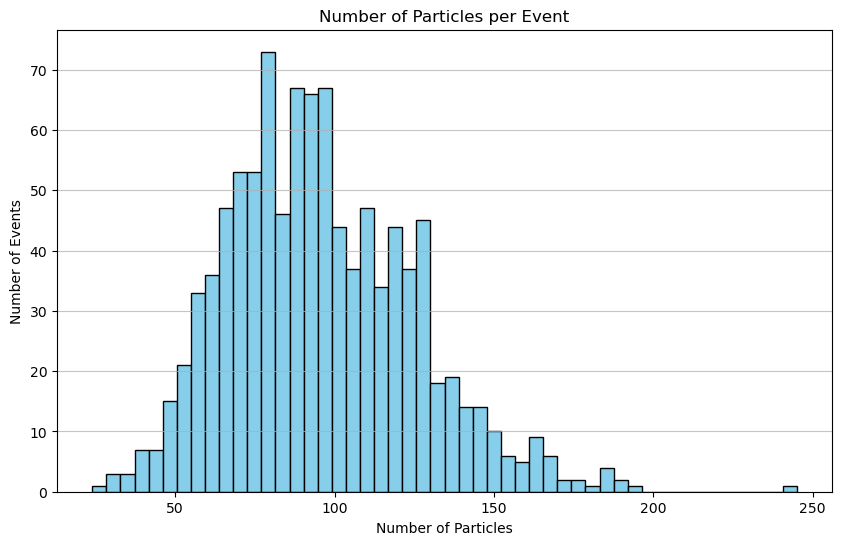

In [43]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = df_particles["particle_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

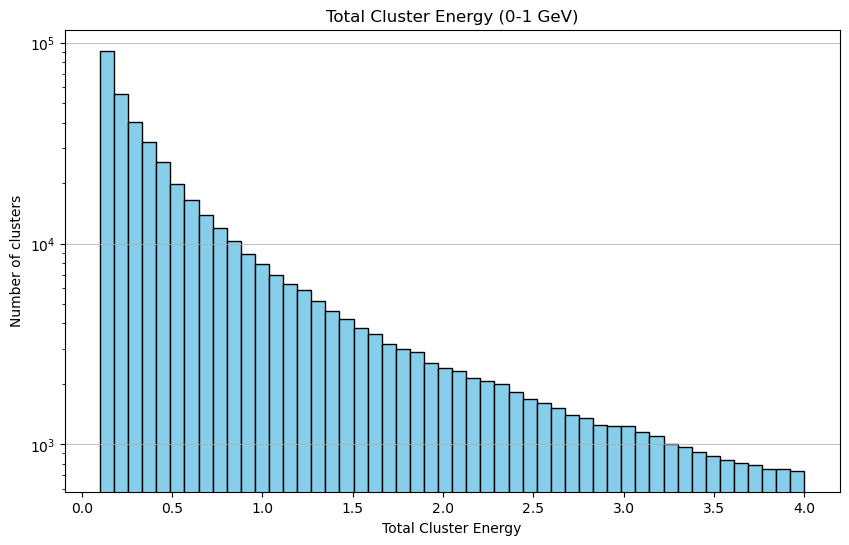

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate number of particles per event from target_particles
n_particles = df_clusters.select(pl.col("total_cluster_energy")).explode("total_cluster_energy").to_series().to_numpy()

# Filter to only show values between 0 and 1
n_particles_filtered = n_particles[(n_particles >= 0.001) & (n_particles <= 4)]

plt.figure(figsize=(10, 6))
plt.hist(n_particles_filtered, bins=50, color='skyblue', edgecolor='black')
plt.title('Total Cluster Energy (0-1 GeV)')
plt.xlabel('Total Cluster Energy')
plt.ylabel('Number of clusters')
plt.grid(axis='y', alpha=0.75)
# log scale for y-axis
plt.yscale('log')
plt.show()


In [18]:
n_particles[n_particles >0.2]

array([117.03854313,  13.86952996,  12.28912435, ...,   1.79472281,
         0.34835327,   0.53988441], shape=(35417,))

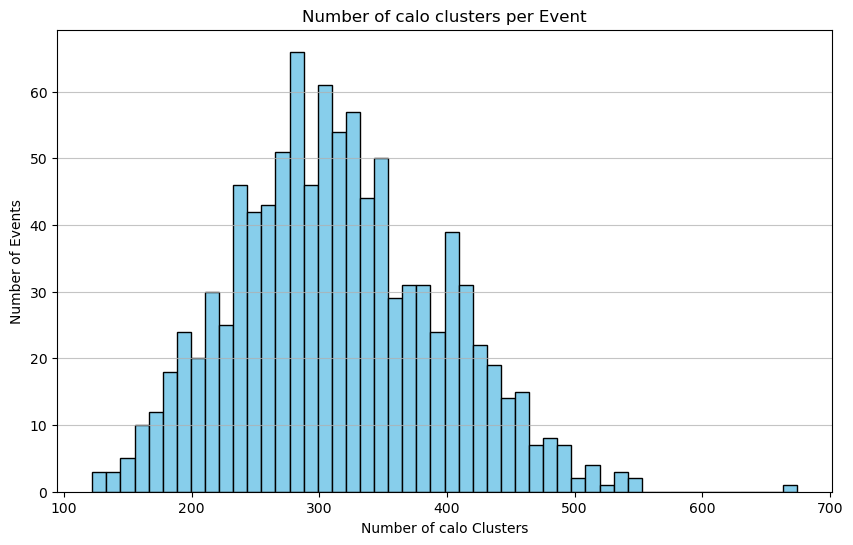

In [44]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = df_clusters["cluster_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of calo clusters per Event')
plt.xlabel('Number of calo Clusters')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Explode the energy list to get individual particle energies
particle_energies = target_particles["energy"].explode()

plt.figure(figsize=(10, 6))
plt.hist(particle_energies, bins=100, color='salmon', edgecolor='black')
plt.title('Target Particle Energy Distribution')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of Particles')
plt.yscale('log') # Using log scale as energy distributions often span orders of magnitude
plt.grid(axis='y', alpha=0.75)
plt.show()